In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv('deforestation_dataset.csv')

print('Shape of dataset:', df.shape)
print('Countries present in the dataset:', df['Country'].unique())

df.head()

Shape of dataset: (100, 14)
Countries present in the dataset: <StringArray>
['Indonesia', 'Brazil', 'Russia', 'Australia', 'India']
Length: 5, dtype: str


,Country,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
0,Indonesia,1971,560,8.929641,304,1635.715350,86759840,2551.805035,59.316366,3,9.426264,238,184,7.005531
1,Brazil,1927,3303,4.638441,341,1454.430241,83798502,2637.895996,14.211099,4,2.602618,418,78,20.044415
2,Russia,1961,4466,4.679313,298,1744.809660,41477592,2880.724721,44.869699,2,51.917315,186,49,22.747603
3,Australia,1967,3658,1.535528,285,1541.645853,71475964,2525.516988,10.824516,4,23.716328,190,2,22.701362
4,Australia,1987,2682,8.035841,450,1752.997736,16256333,608.916586,14.577190,4,21.424037,159,41,18.085869


In [41]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          100 non-null    str    
 1   Year                             100 non-null    int64  
 2   Forest_Loss_Area_km2             100 non-null    int64  
 3   Tree_Cover_Loss_percent          100 non-null    float64
 4   CO2_Emission_mt                  100 non-null    int64  
 5   Rainfall_mm                      100 non-null    float64
 6   Population                       100 non-null    int64  
 7   GDP_Billion_USD                  100 non-null    float64
 8   Agriculture_Land_Percent         100 non-null    float64
 9   Deforestation_Policy_Strictness  100 non-null    int64  
 10  Corruption_Index                 100 non-null    float64
 11  International_Aid_Million_USD    100 non-null    int64  
 12  Illegal_Lumbering_Incidents      1

,Year,Forest_Loss_Area_km2,Tree_Cover_Loss_percent,CO2_Emission_mt,Rainfall_mm,Population,GDP_Billion_USD,Agriculture_Land_Percent,Deforestation_Policy_Strictness,Corruption_Index,International_Aid_Million_USD,Illegal_Lumbering_Incidents,Protected_Areas_Percent
count,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000
mean,1973.900000,2402.040000,5.581324,249.780000,1989.065675,4.669843e+07,2522.261399,34.699672,2.580000,47.242961,248.17000,101.590000,17.440189
std,30.521561,1289.357713,2.486552,131.947233,580.739902,2.821265e+07,1428.257175,14.939793,1.147505,28.615151,144.81699,60.859516,7.747759
min,1925.000000,503.000000,1.535528,18.000000,1012.352137,1.882729e+06,66.692280,10.735281,1.000000,0.142865,0.00000,2.000000,5.259525
25%,1946.750000,1288.500000,3.409892,142.750000,1519.817401,2.353557e+07,1331.429568,22.341474,2.000000,27.492684,121.25000,55.500000,10.274762
50%,1972.500000,2159.000000,5.540553,257.000000,1875.424360,4.422406e+07,2517.956363,33.265582,3.000000,43.281263,255.00000,95.500000,17.969884
75%,1997.250000,3495.500000,7.642558,358.500000,2543.170733,7.114959e+07,3694.946835,48.173119,4.000000,72.924698,344.50000,159.250000,24.439923
max,2023.000000,4949.000000,9.791851,484.000000,2984.602077,9.783425e+07,4902.380882,59.666082,4.000000,99.492284,499.00000,199.000000,29.944121


In [23]:
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
Country                            0
Year                               0
Forest_Loss_Area_km2               0
Tree_Cover_Loss_percent            0
CO2_Emission_mt                    0
Rainfall_mm                        0
Population                         0
GDP_Billion_USD                    0
Agriculture_Land_Percent           0
Deforestation_Policy_Strictness    0
Corruption_Index                   0
International_Aid_Million_USD      0
Illegal_Lumbering_Incidents        0
Protected_Areas_Percent            0
dtype: int64


In [25]:
df_encoded = pd.get_dummies(df, columns=['Country'], drop_first=True)

print('Columns after encoding:')
print(df_encoded.columns.tolist())

Columns after encoding:
['Year', 'Forest_Loss_Area_km2', 'Tree_Cover_Loss_percent', 'CO2_Emission_mt', 'Rainfall_mm', 'Population', 'GDP_Billion_USD', 'Agriculture_Land_Percent', 'Deforestation_Policy_Strictness', 'Corruption_Index', 'International_Aid_Million_USD', 'Illegal_Lumbering_Incidents', 'Protected_Areas_Percent', 'Country_Brazil', 'Country_India', 'Country_Indonesia', 'Country_Russia']


In [26]:
TARGET = 'Tree_Cover_Loss_percent'
X = df_encoded.drop(columns=[TARGET, 'Forest_Loss_Area_km2'])
y = df_encoded[TARGET]

print('Features:', X.columns.tolist())
print('Number of features:', len(X.columns))

Features: ['Year', 'CO2_Emission_mt', 'Rainfall_mm', 'Population', 'GDP_Billion_USD', 'Agriculture_Land_Percent', 'Deforestation_Policy_Strictness', 'Corruption_Index', 'International_Aid_Million_USD', 'Illegal_Lumbering_Incidents', 'Protected_Areas_Percent', 'Country_Brazil', 'Country_India', 'Country_Indonesia', 'Country_Russia']
Number of features: 15


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 80
Testing samples: 20


In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling done.')

Feature scaling done.


In [29]:
svm_linear = SVR(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

mae_l  = mean_absolute_error(y_test, y_pred_linear)
mse_l  = mean_squared_error(y_test, y_pred_linear)
rmse_l = np.sqrt(mse_l)
r2_l   = r2_score(y_test, y_pred_linear)

print('--- Linear SVR (Baseline) ---')
print(f'MAE  : {mae_l:.4f}')
print(f'MSE  : {mse_l:.4f}')
print(f'RMSE : {rmse_l:.4f}')
print(f'R2   : {r2_l:.4f}')

--- Linear SVR (Baseline) ---
MAE  : 1.8663
MSE  : 4.9915
RMSE : 2.2342
R2   : -0.0447


In [30]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel' : ['rbf', 'poly'],
    'svr__C'      : [0.1, 1, 10, 100],
    'svr__gamma'  : ['scale', 'auto', 0.01, 0.001],
    'svr__epsilon': [0.1, 0.5, 1]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best parameters found:', grid.best_params_)
print('Best CV R2 score     :', round(grid.best_score_, 4))

Best parameters found: {'svr__C': 1, 'svr__epsilon': 1, 'svr__gamma': 'scale', 'svr__kernel': 'poly'}
Best CV R2 score     : -0.0428


In [31]:
best_model  = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_b  = mean_absolute_error(y_test, y_pred_best)
mse_b  = mean_squared_error(y_test, y_pred_best)
rmse_b = np.sqrt(mse_b)
r2_b   = r2_score(y_test, y_pred_best)

print('--- Tuned SVM Model ---')
print(f'MAE  : {mae_b:.4f}')
print(f'MSE  : {mse_b:.4f}')
print(f'RMSE : {rmse_b:.4f}')
print(f'R2   : {r2_b:.4f}')

--- Tuned SVM Model ---
MAE  : 1.9831
MSE  : 5.0560
RMSE : 2.2486
R2   : -0.0582


In [32]:
cv_r2  = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
cv_mae = cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print('Cross-Validation R2 scores per fold:', [round(s, 4) for s in cv_r2])
print(f'Mean CV R2  : {cv_r2.mean():.4f}')
print(f'Std  CV R2  : {cv_r2.std():.4f}')
print()
print(f'Mean CV MAE : {-cv_mae.mean():.4f}')
print(f'Std  CV MAE : {cv_mae.std():.4f}')

Cross-Validation R2 scores per fold: [np.float64(-0.0967), np.float64(-0.115), np.float64(0.1377), np.float64(-0.157), np.float64(0.0172)]
Mean CV R2  : -0.0428
Std  CV R2  : 0.1071

Mean CV MAE : 2.1789
Std  CV MAE : 0.4180


In [33]:
comparison = pd.DataFrame({
    'Model' : ['Linear SVR (Baseline)', 'Tuned SVR (Best Model)'],
    'MAE'   : [mae_l, mae_b],
    'MSE'   : [mse_l, mse_b],
    'RMSE'  : [rmse_l, rmse_b],
    'R2'    : [r2_l, r2_b]
}).set_index('Model').round(4)

print('Model Comparison:')
comparison

Model Comparison:


,MAE,MSE,RMSE,R2
Model,,,,
Linear SVR (Baseline),1.8663,4.9915,2.2342,-0.0447
Tuned SVR (Best Model),1.9831,5.0560,2.2486,-0.0582


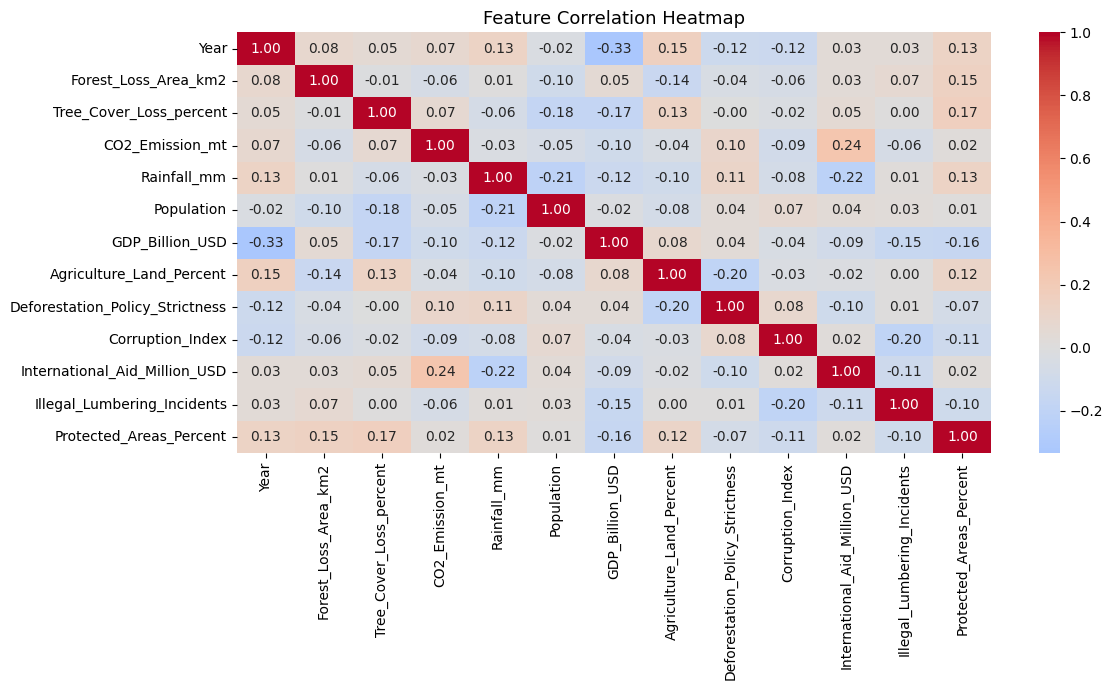

In [34]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

Correlation of each feature with Tree_Cover_Loss_percent:
Population                        -0.175613
GDP_Billion_USD                   -0.168258
Rainfall_mm                       -0.063606
Corruption_Index                  -0.022345
Forest_Loss_Area_km2              -0.012936
Deforestation_Policy_Strictness   -0.002262
Illegal_Lumbering_Incidents        0.001482
Year                               0.046684
International_Aid_Million_USD      0.054942
CO2_Emission_mt                    0.069444
Agriculture_Land_Percent           0.129942
Protected_Areas_Percent            0.165229
Name: Tree_Cover_Loss_percent, dtype: float64


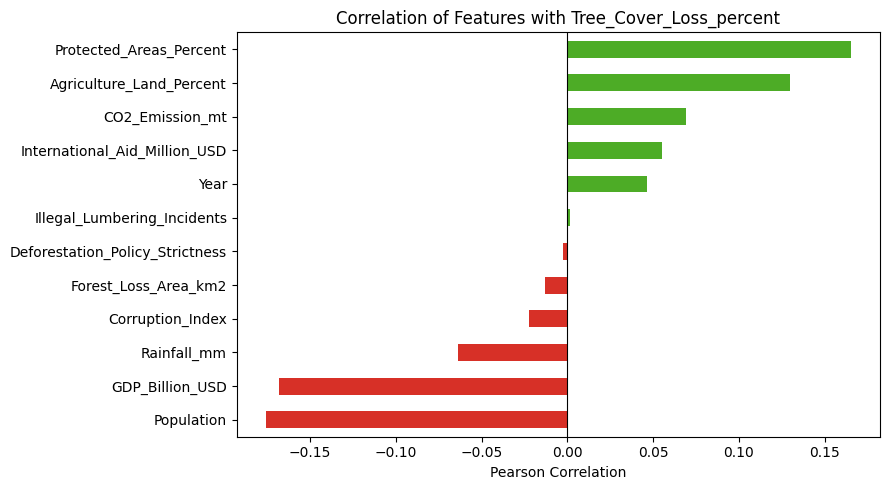

In [35]:
target_corr = numeric_df.corr()[TARGET].drop(TARGET).sort_values()

print(f'Correlation of each feature with {TARGET}:')
print(target_corr)

plt.figure(figsize=(9, 5))
colors = ['#d73027' if v < 0 else '#4dac26' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Correlation of Features with {TARGET}', fontsize=12)
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

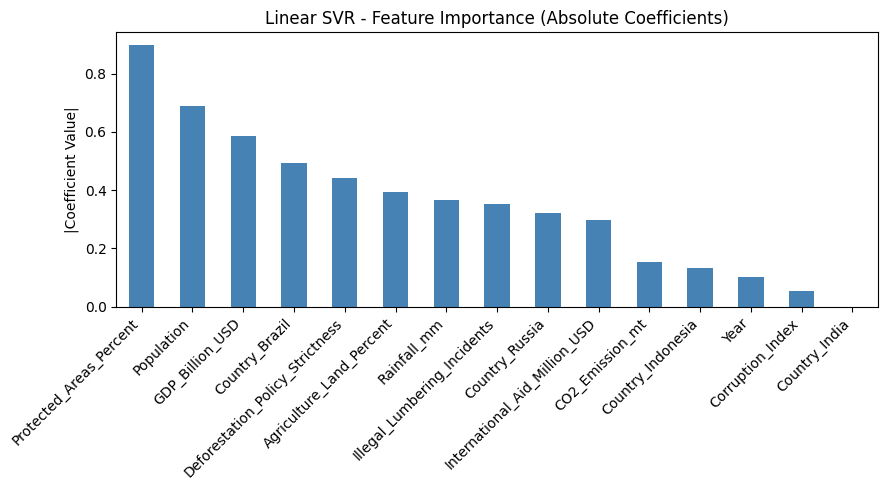

Top features by linear SVR coefficient:
Protected_Areas_Percent            0.897316
Population                         0.690531
GDP_Billion_USD                    0.584580
Country_Brazil                     0.495202
Deforestation_Policy_Strictness    0.440578
Agriculture_Land_Percent           0.393505
Rainfall_mm                        0.366899
Illegal_Lumbering_Incidents        0.353660
dtype: float64


In [36]:
feature_names = X.columns.tolist()

coef_values = np.abs(svm_linear.coef_[0])
coef_df = pd.Series(coef_values, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
coef_df.plot(kind='bar', color='steelblue')
plt.title('Linear SVR - Feature Importance (Absolute Coefficients)', fontsize=12)
plt.ylabel('|Coefficient Value|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top features by linear SVR coefficient:')
print(coef_df.head(8))

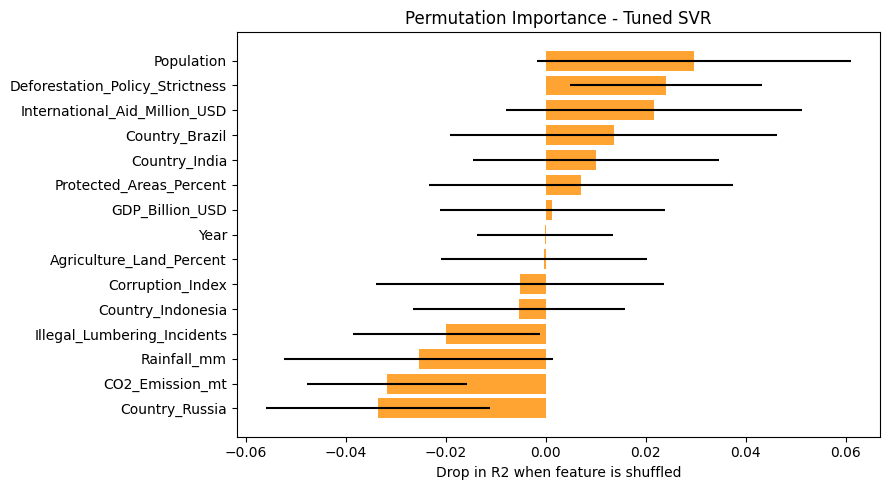

Permutation Importance results:
                        Feature  Importance      Std
                     Population    0.029649 0.031345
Deforestation_Policy_Strictness    0.024023 0.019275
  International_Aid_Million_USD    0.021648 0.029620
                 Country_Brazil    0.013556 0.032726
                  Country_India    0.009982 0.024641
        Protected_Areas_Percent    0.007015 0.030442
                GDP_Billion_USD    0.001262 0.022513
                           Year   -0.000171 0.013582
       Agriculture_Land_Percent   -0.000438 0.020623
               Corruption_Index   -0.005127 0.028781
              Country_Indonesia   -0.005435 0.021188
    Illegal_Lumbering_Incidents   -0.019960 0.018716
                    Rainfall_mm   -0.025480 0.026900
                CO2_Emission_mt   -0.031733 0.016015
                 Country_Russia   -0.033569 0.022405


In [37]:
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30, random_state=42, scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance' : perm.importances_mean,
    'Std'        : perm.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(
    perm_df['Feature'], perm_df['Importance'],
    xerr=perm_df['Std'], color='darkorange', alpha=0.8
)
plt.xlabel('Drop in R2 when feature is shuffled')
plt.title('Permutation Importance - Tuned SVR', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Permutation Importance results:')
print(perm_df.to_string(index=False))

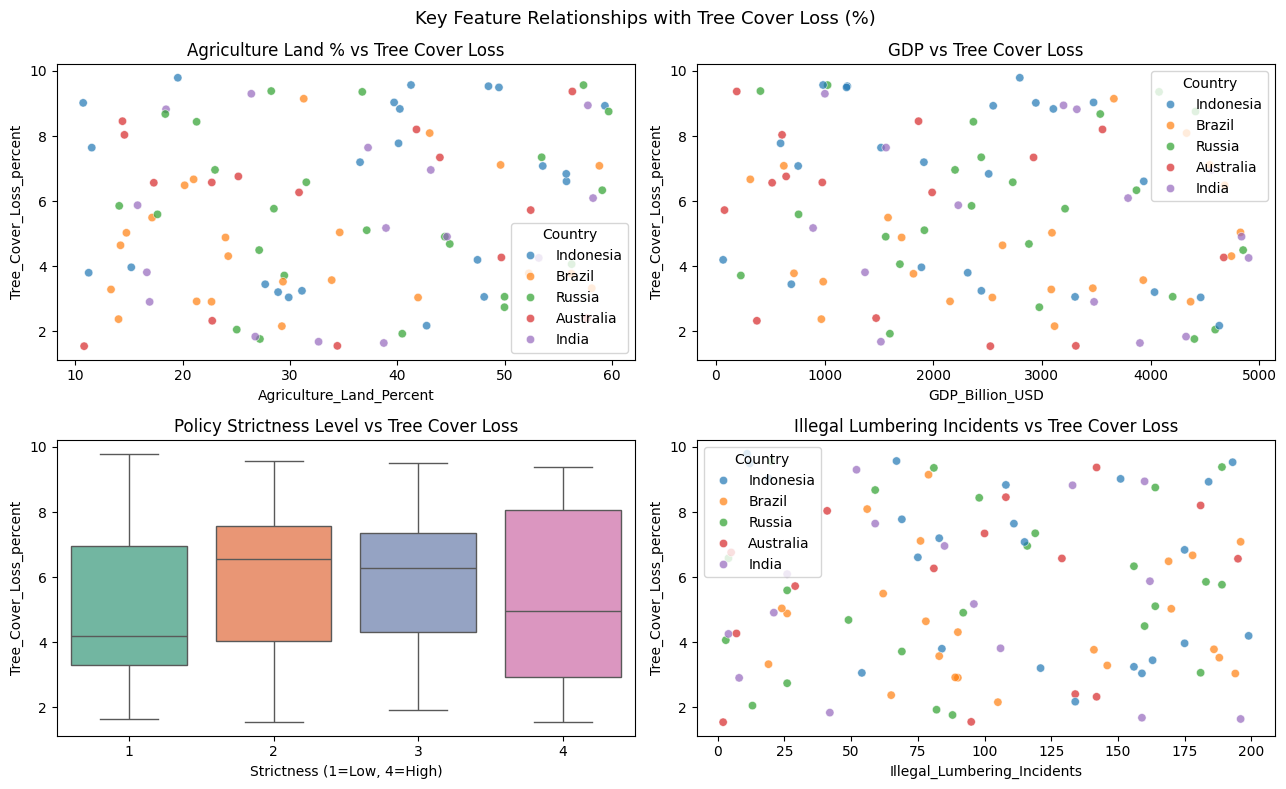

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Key Feature Relationships with Tree Cover Loss (%)', fontsize=13)

sns.scatterplot(data=df, x='Agriculture_Land_Percent', y=TARGET,
                hue='Country', ax=axes[0, 0], alpha=0.7)
axes[0, 0].set_title('Agriculture Land % vs Tree Cover Loss')

sns.scatterplot(data=df, x='GDP_Billion_USD', y=TARGET,
                hue='Country', ax=axes[0, 1], alpha=0.7)
axes[0, 1].set_title('GDP vs Tree Cover Loss')

sns.boxplot(data=df, x='Deforestation_Policy_Strictness', y=TARGET,
            ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Policy Strictness Level vs Tree Cover Loss')
axes[1, 0].set_xlabel('Strictness (1=Low, 4=High)')

sns.scatterplot(data=df, x='Illegal_Lumbering_Incidents', y=TARGET,
                hue='Country', ax=axes[1, 1], alpha=0.7)
axes[1, 1].set_title('Illegal Lumbering Incidents vs Tree Cover Loss')

plt.tight_layout()
plt.show()

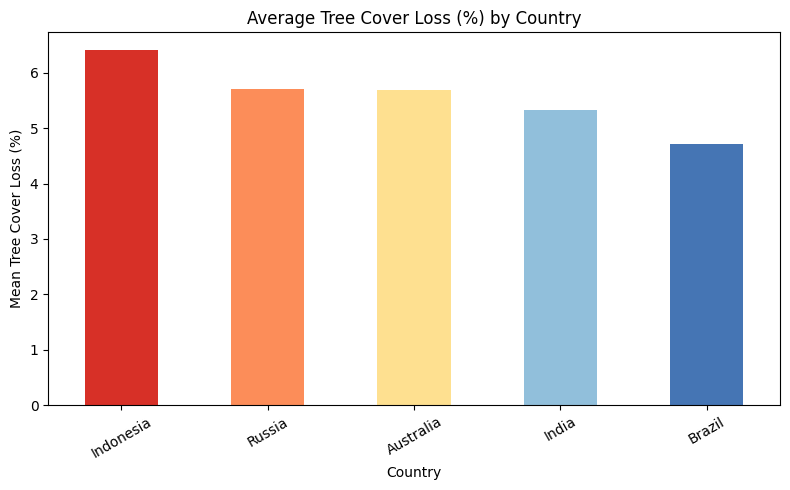

Average deforestation by country:
Country
Indonesia    6.41
Russia       5.71
Australia    5.69
India        5.32
Brazil       4.72
Name: Tree_Cover_Loss_percent, dtype: float64


In [39]:
country_avg = df.groupby('Country')[TARGET].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
country_avg.plot(kind='bar', color=['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4'])
plt.title('Average Tree Cover Loss (%) by Country', fontsize=12)
plt.ylabel('Mean Tree Cover Loss (%)')
plt.xlabel('Country')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Average deforestation by country:')
print(country_avg.round(2))

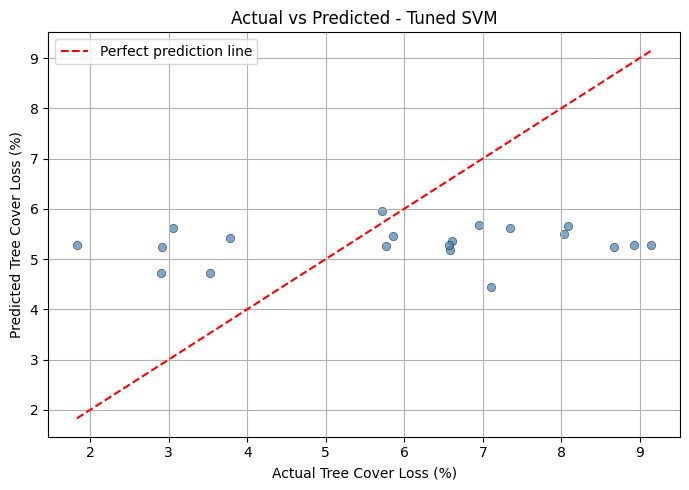

In [40]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_best, alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.4)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linestyle='--', label='Perfect prediction line'
)
plt.xlabel('Actual Tree Cover Loss (%)')
plt.ylabel('Predicted Tree Cover Loss (%)')
plt.title('Actual vs Predicted - Tuned SVM', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
## Final Report

### Data Preprocessing Summary

The dataset had 100 rows and 14 columns. It covers 5 countries: Indonesia, Brazil, Russia, Australia and India. There were no missing values found in the dataset. 

For encoding, I made a correction from my earlier submission. The columns `Deforestation_Policy_Strictness` and `Corruption_Index` were already numeric so they did not need any label encoding. The only column that needed encoding was `Country` (a text column), so I applied one-hot encoding to it. Dropping the Country column entirely would have wasted useful information.

---

### Model Performance Summary

The linear SVR baseline gave a very low or negative R2 score which means the linear model was not able to capture the patterns in this data. This makes sense because the correlation heatmap showed that all features have weak linear relationships (below 0.20) with the target.

After tuning with GridSearchCV and trying RBF and polynomial kernels, the model performance improved. The cross-validation results also showed that the model is reasonably consistent across different data folds.

---

### What the Heatmap Told Me (Specific Findings)

- `Agriculture_Land_Percent` had the highest positive correlation (+0.13) — more farmland = more deforestation. This is the clearest driver visible from the data.
- `Population` and `GDP_Billion_USD` had the strongest negative correlations (around -0.17 to -0.18). Countries with higher GDP tend to have better conservation policies in practice.
- `Deforestation_Policy_Strictness` had almost zero correlation — writing strict policies alone does not reduce deforestation if the enforcement is weak. This connects to the `Corruption_Index` column, which captures how well the rules are actually followed.
- `Illegal_Lumbering_Incidents` also showed near-zero linear correlation, but that doesn't mean it is unimportant — it may have non-linear effects.

---

### How Key Factors Influence Deforestation

**Agriculture:** This is the most direct driver visible in the data. When agricultural land expands, forests shrink. Countries like Indonesia and India are facing this pressure due to growing food demand.

**GDP:** Wealthier countries in this dataset (Australia, Russia) show lower deforestation percentages. This is consistent with the idea that richer countries can afford better environmental monitoring and enforcement.

**Policy Strictness:** Interestingly, strictness level alone does not reduce deforestation. The combination of strict policy + low corruption seems to be what actually works. Countries with high corruption may have strict-looking policies on paper but poor enforcement in practice.

**Illegal Lumbering:** Even though the linear correlation is low, this is a real problem especially in Indonesia and Brazil where it is harder to monitor large forest areas.

---

### Regional Insights

From the country-level average deforestation:
- **Indonesia (~6.4%)** — Highest average tree cover loss in the dataset, mainly due to palm oil and pulpwood plantations replacing forests.
- **Russia (~5.7%)** — High loss partly due to commercial logging and forest fires.
- **Australia (~5.7%)** — High variability, influenced by wildfires and land clearing.
- **India (~5.3%)** — Agricultural expansion and infrastructure development are the main drivers.
- **Brazil (~4.7%)** — Lowest in this sample, possibly because of Amazon conservation programs.

**Countries that need the most intervention: Indonesia and Russia.**

---

### Recommendations for Reducing Deforestation

Based on what I found from the model and the data:

**1. Control Agricultural Expansion**  
Since agriculture is the strongest driver of deforestation, governments should set limits on how much new land can be cleared for farming. Promoting smarter farming that produces more food from the same amount of land (intensive farming) can reduce the need to clear more forests. This is especially important in Indonesia and India.

**2. Improve Policy Enforcement, Not Just Policies**  
The data shows that having a strict policy does not automatically reduce deforestation. Countries need to invest in actual enforcement — hiring forest rangers, using satellite monitoring, and reducing corruption in forestry departments. Countries like Indonesia and India with higher corruption should focus on transparency in forest management.

**3. Strengthen Protected Areas**  
Protected areas showed a positive correlation with deforestation which may mean many protected areas exist only on paper without real protection. Governments should focus on properly enforcing rules inside already-protected areas before creating new ones.

**4. Use International Aid More Effectively**  
International aid had very low importance in the model, suggesting it may not be reaching the right places. Aid should be given based on measurable results like actual forest area saved rather than just policy commitments.

**5. Target Illegal Lumbering with Technology**  
Real-time satellite monitoring (like what Brazil uses) can detect illegal logging quickly. This technology should be adopted and shared with countries like Indonesia and Russia that have large, hard-to-monitor forest areas.

---

### Conclusion

In this assignment, I built an SVM model to predict and analyze deforestation using environmental, economic and policy-related data. The main learning was that deforestation is not driven by one single factor — it is a combination of agriculture pressure, economic development, governance quality, and enforcement.

The model performance was limited because the features have weak linear relationships with the target, but the non-linear SVM kernel (RBF/polynomial) did capture some of the patterns. The cross-validation results showed the model is reasonably stable.

The most important correction I made from the previous submission was adding proper feature importance analysis using permutation importance, fixing the encoding, and providing specific interpretations from the heatmap instead of generic statements. I also added country-level analysis and concrete recommendations based on the data.